## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, classification_report, accuracy_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42


## 2. Load data

Reads `huntingtons_ML_dataset_GSE33000.csv` — prefrontal cortex brain tissue,
custom Agilent array (GPL4372). This dataset originally contains three
groups (Alzheimer's disease, Huntington's disease, non-demented control);
the extraction pipeline excluded AD samples (`EXCLUDE_ALZHEIMERS = True`),
leaving a clean binary HD-vs-control comparison.

Gene panel for this run: `IGF2BP1, IGF2BP2, ALYREF, METTL14, METTL16` — a
different 5-gene m6A panel than the 12-gene panel used in the other three
notebooks (GSE3790/GSE64810/GSE1751).

Column layout:
- `Sample_ID` — GSM accession (identifier column, dropped from features)
- `Huntingtons_Disease` — target column (1 = HD, 0 = non-demented control)
- gene-symbol columns — probe-averaged, same approach as GSE3790/GSE1751.

Note: this notebook lives in `models/`, one level below the project root,
so `DATA_PATH` uses `../datasets/...` to reach the shared datasets folder.

In [4]:
DATA_PATH = "../datasets/GSE33000_Huntington_dataset.csv"
ID_COL = "Sample_ID"
TARGET_COL = "Huntingtons_Disease"

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(314, 14)


,Sample_ID,Huntingtons_Disease,IGF2BP1,IGF2BP3,YTHDC1,PPP1CC,YTHDF2,CEBPD,YTHDF3,FTO,IGF2BP2,CEBPB,YTHDC2,YTHDF1
0,GSM1424090,0,0.016574,-0.077928,-0.072330,-0.197667,-0.000080,0.345330,-0.025922,0.055944,0.031448,0.034834,-0.074580,0.222237
1,GSM1424091,0,0.006074,0.027267,-0.058254,-0.059976,-0.001925,-0.608529,-0.016600,0.026025,-0.186957,-0.176628,0.024177,-0.106046
2,GSM1424092,0,-0.051499,-0.034081,0.059579,-0.062763,0.032267,-0.098041,0.017265,0.097491,-0.085084,-0.083139,0.018757,-0.064697
3,GSM1424093,0,-0.015612,-0.047516,0.049971,-0.055974,-0.034365,-0.164657,0.004248,0.058491,-0.071076,-0.097935,-0.019982,-0.040829
4,GSM1424094,0,0.015252,0.005811,-0.032221,-0.024726,0.040895,-0.315075,-0.015421,0.056628,-0.097269,-0.169396,0.062169,-0.091807


In [5]:
feature_cols = [c for c in df.columns if c not in (ID_COL, TARGET_COL)]

X = df[feature_cols]
y = df[TARGET_COL]

print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")
print("Features:", feature_cols)
print("\nClass balance:")
print(y.value_counts())


Samples: 314, Features: 12
Features: ['IGF2BP1', 'IGF2BP3', 'YTHDC1', 'PPP1CC', 'YTHDF2', 'CEBPD', 'YTHDF3', 'FTO', 'IGF2BP2', 'CEBPB', 'YTHDC2', 'YTHDF1']

Class balance:
Huntingtons_Disease
0    157
1    157
Name: count, dtype: int64


## 3. Impute + scale

In [6]:
X_imputed = SimpleImputer(strategy="mean").fit_transform(X)
X_scaled = StandardScaler().fit_transform(X_imputed)


## 4. Train/test split

Stratified so both classes are represented in the test set. Check the
printed class counts below before trusting the results.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train class balance:")
print(y_train.value_counts())
print("\nTest class balance:")
print(y_test.value_counts())


Train class balance:
Huntingtons_Disease
1    126
0    125
Name: count, dtype: int64

Test class balance:
Huntingtons_Disease
0    32
1    31
Name: count, dtype: int64


## 5. Models + hyperparameter grids

In [8]:
from sklearn.calibration import CalibratedClassifierCV

models = {
    "SVM": {
        "model": CalibratedClassifierCV(SVC(random_state=RANDOM_STATE), ensemble=False),
        "params": {
            "estimator__C": [0.1, 1, 10],
            "estimator__kernel": ["linear", "rbf"],
        },
    },
    "GLM": {
        "model": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "params": {
            "C": [0.1, 1, 10],
        },
    },
    "RandomForest": {
        "model": RandomForestClassifier(random_state=RANDOM_STATE),
        "params": {
            "n_estimators": [100, 200, 300, 400],
            "max_depth": [1 ,2 , 3, 5],
            "min_samples_split": [2, 5],
            "min_samples_leaf": [1, 2],
        },
    },
    "XGBoost": {
        "model": XGBClassifier(
            eval_metric="logloss",
            random_state=RANDOM_STATE,
        ),
        "params": {
            "n_estimators": [100, 200, 400],
            "max_depth": [2, 3, 5],
            "learning_rate": [0.01, 0.05, 0.1],
            "subsample": [0.8, 1.0],
        },
    },
}


## 6. GridSearchCV for each model

Uses `StratifiedKFold` so class balance is preserved in every fold.
`n_splits` is capped at the smallest class count in the training set so
GridSearchCV doesn't fail on a fold with zero positive examples.

In [9]:
best_models = {}
roc_data = {}

min_class_count = y_train.value_counts().min()
print(f"Min class split {min_class_count}")
n_splits = max(2, min(5, min_class_count))
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
print(f"Using {n_splits}-fold StratifiedKFold for GridSearchCV")


Min class split 125
Using 5-fold StratifiedKFold for GridSearchCV


In [10]:
for name, mp in models.items():
    clf = GridSearchCV(
        mp["model"], mp["params"], cv=cv, scoring="roc_auc", n_jobs=1
    )
    clf.fit(X_train, y_train)

    best_models[name] = clf.best_estimator_

    y_prob = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    roc_data[name] = (fpr, tpr, roc_auc)

    print(f"Best {name} params: {clf.best_params_}")
    print(f"  CV best ROC-AUC: {clf.best_score_:.4f}  |  Test ROC-AUC: {roc_auc:.4f}")


Best SVM params: {'estimator__C': 10, 'estimator__kernel': 'rbf'}
  CV best ROC-AUC: 0.9678  |  Test ROC-AUC: 0.9365
Best GLM params: {'C': 0.1}
  CV best ROC-AUC: 0.9224  |  Test ROC-AUC: 0.9103
Best RandomForest params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
  CV best ROC-AUC: 0.9378  |  Test ROC-AUC: 0.8992
Best XGBoost params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
  CV best ROC-AUC: 0.9453  |  Test ROC-AUC: 0.9042


## 7. ROC curve comparison

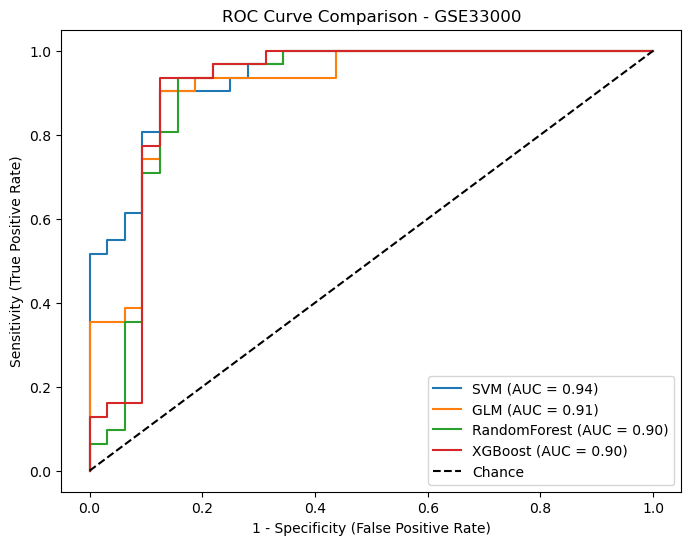

In [15]:
plt.figure(figsize=(8, 6))
for name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.xlabel("1 - Specificity (False Positive Rate)")
plt.ylabel("Sensitivity (True Positive Rate)")
plt.title("ROC Curve Comparison - GSE33000")
plt.legend(loc="lower right")
plt.show()


## 8. Detailed evaluation per model

Accuracy, confusion matrix, and classification report for each tuned model
on the held-out test set.

EVALUATION: SVM
Accuracy: 0.8730
True Negatives (TN): 28
False Positives (FP): 4
False Negatives (FN): 4
True Positives (TP): 27

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        32
           1       0.87      0.87      0.87        31

    accuracy                           0.87        63
   macro avg       0.87      0.87      0.87        63
weighted avg       0.87      0.87      0.87        63



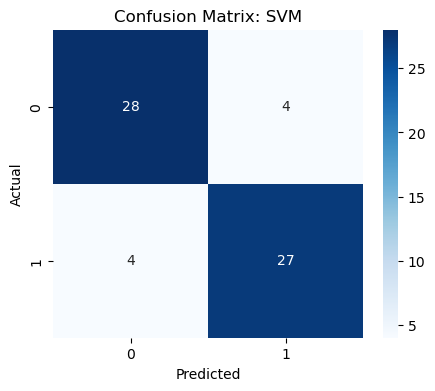

EVALUATION: GLM
Accuracy: 0.8571
True Negatives (TN): 28
False Positives (FP): 4
False Negatives (FN): 5
True Positives (TP): 26

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.88      0.86        32
           1       0.87      0.84      0.85        31

    accuracy                           0.86        63
   macro avg       0.86      0.86      0.86        63
weighted avg       0.86      0.86      0.86        63



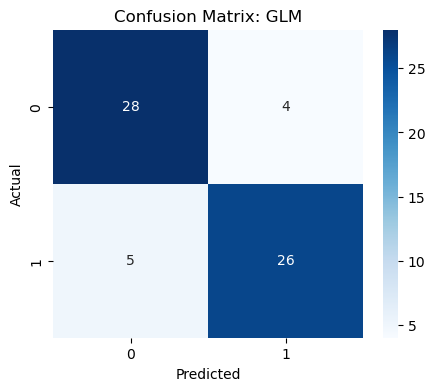

EVALUATION: RandomForest
Accuracy: 0.8571
True Negatives (TN): 27
False Positives (FP): 5
False Negatives (FN): 4
True Positives (TP): 27

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.84      0.86        32
           1       0.84      0.87      0.86        31

    accuracy                           0.86        63
   macro avg       0.86      0.86      0.86        63
weighted avg       0.86      0.86      0.86        63



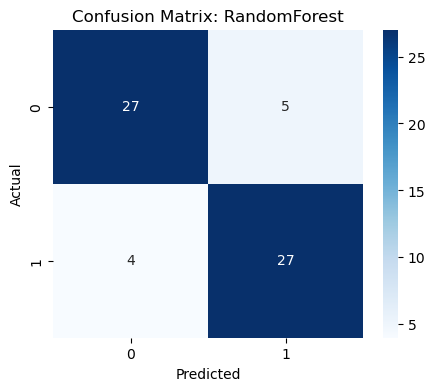

EVALUATION: XGBoost
Accuracy: 0.8889
True Negatives (TN): 28
False Positives (FP): 4
False Negatives (FN): 3
True Positives (TP): 28

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89        32
           1       0.88      0.90      0.89        31

    accuracy                           0.89        63
   macro avg       0.89      0.89      0.89        63
weighted avg       0.89      0.89      0.89        63



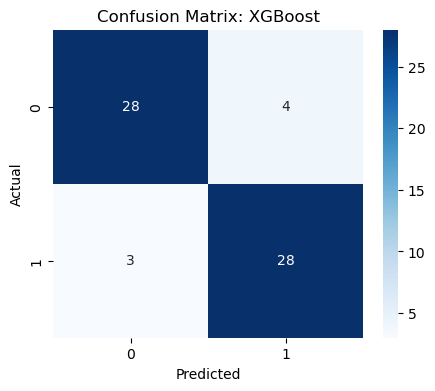

In [16]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    print(f"{'='*20}")
    print(f"EVALUATION: {model_name}")
    print(f"{'='*20}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"True Negatives (TN): {tn}")
    print(f"False Positives (FP): {fp}")
    print(f"False Negatives (FN): {fn}")
    print(f"True Positives (TP): {tp}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


for name, model in best_models.items():
    evaluate_model(model, X_test, y_test, name)


## 9. Feature importance (RandomForest & XGBoost)

Which of the 5 genes (IGF2BP1, IGF2BP2, ALYREF, METTL14, METTL16) are
driving predictions in this brain-tissue cohort.

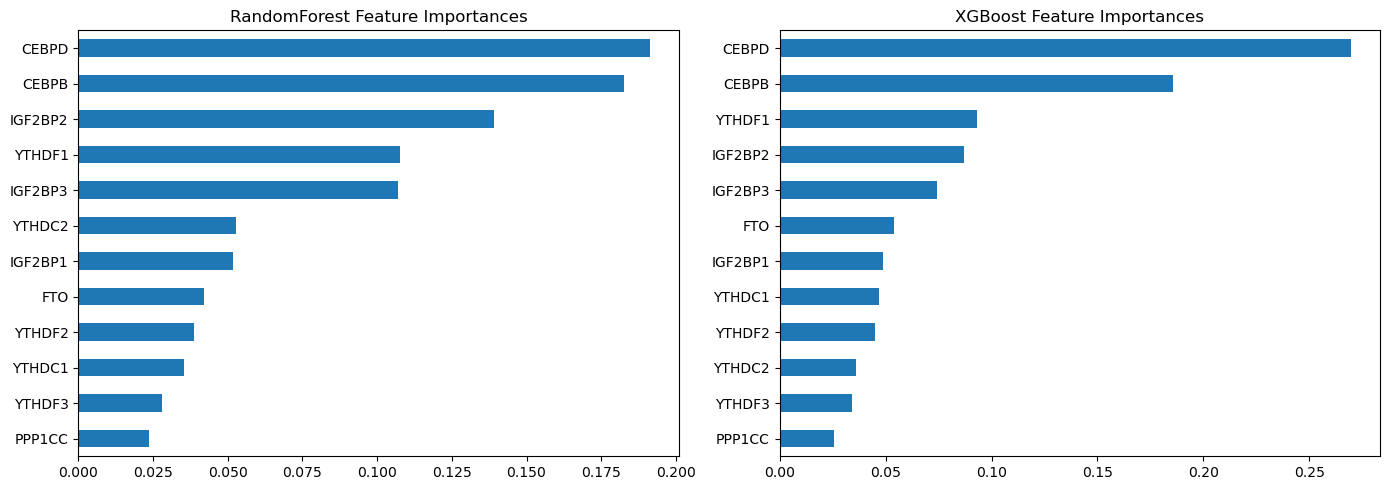

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name in zip(axes, ["RandomForest", "XGBoost"]):
    model = best_models[name]
    importances = pd.Series(model.feature_importances_, index=feature_cols)
    importances = importances.sort_values(ascending=True)
    importances.plot(kind="barh", ax=ax)
    ax.set_title(f"{name} Feature Importances")

plt.tight_layout()
plt.show()


In [18]:
print("Genes present in this dataset:", feature_cols)
print("Count:", len(feature_cols))


Genes present in this dataset: ['IGF2BP1', 'IGF2BP3', 'YTHDC1', 'PPP1CC', 'YTHDF2', 'CEBPD', 'YTHDF3', 'FTO', 'IGF2BP2', 'CEBPB', 'YTHDC2', 'YTHDF1']
Count: 12


## 10. Per-gene ROC curves (individually trained single-feature models)

For each available gene, a **separate Logistic Regression model is trained
using only that one gene as its input feature**. Predictions are made using
`cross_val_predict` with the same `StratifiedKFold` scheme used for the
multivariate models in Section 6, so every sample gets an out-of-fold
predicted probability (i.e. the model never sees a sample's own label when
predicting it) — this is a real trained-model ROC curve per gene, not just a
raw-value threshold sweep.

In [19]:
from sklearn.model_selection import cross_val_predict

gene_roc_data = {}
gene_models = {}

gene_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

for gene in feature_cols:
    # Single-feature input: reshape to (n_samples, 1)
    gene_X = X[[gene]].values
    gene_X_imputed = SimpleImputer(strategy="mean").fit_transform(gene_X)
    gene_X_scaled = StandardScaler().fit_transform(gene_X_imputed)

    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

    # Out-of-fold predicted probabilities: each sample's prediction comes from
    # a model that was NOT trained on that sample
    y_prob = cross_val_predict(
        model, gene_X_scaled, y, cv=gene_cv, method="predict_proba"
    )[:, 1]

    fpr, tpr, _ = roc_curve(y, y_prob)
    gene_auc = auc(fpr, tpr)
    gene_roc_data[gene] = (fpr, tpr, gene_auc)

    # Also fit on the full data for reference (e.g. if you want coefficients later)
    gene_models[gene] = model.fit(gene_X_scaled, y)

# Sort genes by AUC (distance from 0.5, since a gene could be predictive in
# either direction depending on whether it's up- or down-regulated in HD)
gene_roc_data = dict(
    sorted(gene_roc_data.items(), key=lambda kv: abs(kv[1][2] - 0.5), reverse=True)
)

print("Per-gene AUC (individually trained single-feature Logistic Regression, cross-validated):")
for gene, (_, _, gene_auc) in gene_roc_data.items():
    print(f"  {gene}: AUC = {gene_auc:.3f}")


Per-gene AUC (individually trained single-feature Logistic Regression, cross-validated):
  CEBPB: AUC = 0.881
  CEBPD: AUC = 0.880
  IGF2BP2: AUC = 0.860
  YTHDF1: AUC = 0.843
  YTHDC2: AUC = 0.828
  IGF2BP3: AUC = 0.822
  IGF2BP1: AUC = 0.755
  YTHDC1: AUC = 0.703
  FTO: AUC = 0.614
  YTHDF3: AUC = 0.556
  YTHDF2: AUC = 0.536
  PPP1CC: AUC = 0.518


### 10a. All genes overlaid on one plot

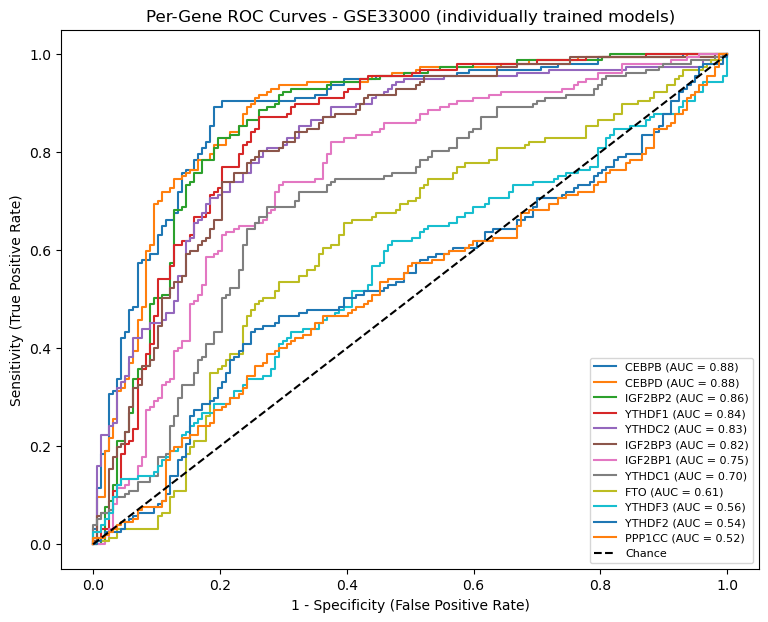

In [20]:
plt.figure(figsize=(9, 7))
for gene, (fpr, tpr, gene_auc) in gene_roc_data.items():
    plt.plot(fpr, tpr, label=f"{gene} (AUC = {gene_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.xlabel("1 - Specificity (False Positive Rate)")
plt.ylabel("Sensitivity (True Positive Rate)")
plt.title("Per-Gene ROC Curves - GSE33000 (individually trained models)")
plt.legend(loc="lower right", fontsize=8)
plt.show()


### 10b. Individual small-multiple panels (one subplot per gene)

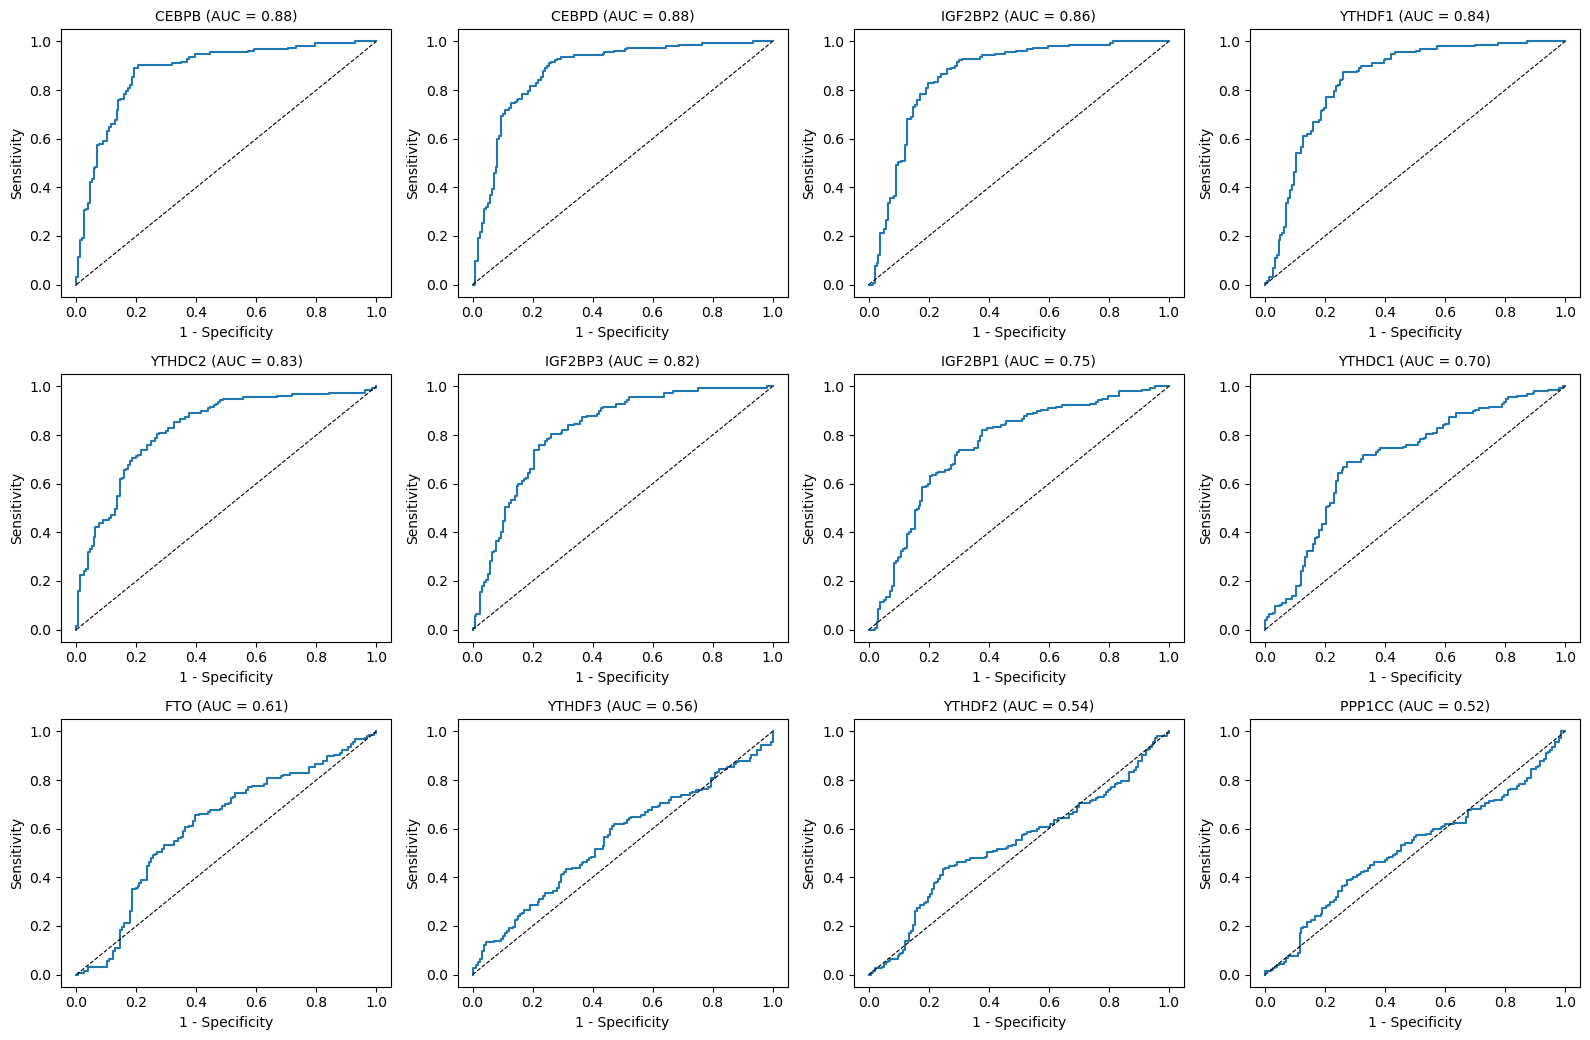

In [21]:
n_genes = len(gene_roc_data)
n_cols = 4
n_rows = -(-n_genes // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
axes = axes.flatten() if n_genes > 1 else [axes]

for ax, (gene, (fpr, tpr, gene_auc)) in zip(axes, gene_roc_data.items()):
    ax.plot(fpr, tpr, color="tab:blue")
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
    ax.set_title(f"{gene} (AUC = {gene_auc:.2f})", fontsize=10)
    ax.set_xlabel("1 - Specificity")
    ax.set_ylabel("Sensitivity")

# Hide any unused subplot axes
for ax in axes[n_genes:]:
    ax.axis("off")

plt.tight_layout()
plt.show()
